In [1]:
import pandas as pd
import numpy as np

# Read the options data file
options_data = pd.read_excel('spx_options_data.xlsx')

# Split data into calls and puts
call_options = options_data[options_data['Type'] == 'Call']
put_options = options_data[options_data['Type'] == 'Put']

# Set the current index price
current_index_price = call_options['Strike'].iloc[0]/(1-call_options['Moneyness'].iloc[0])

# Update the moneyness for calls and puts to K/S
call_options['Moneyness'] = call_options['Strike'] / current_index_price
put_options['Moneyness'] = put_options['Strike'] / current_index_price

# Print the first and last few rows of each dataset


print("\nFirst few rows of Put options:")
print(put_options.head())
print("\nLast few rows of Put options:")
print(put_options.tail())

print("\nFirst few rows of Call options:")
print(call_options.head())
print("\nLast few rows of Call options:")
print(call_options.tail())


# Calculate forward price using put-call parity
# For ATM options (Moneyness closest to 1)
atm_call = call_options.iloc[(call_options['Moneyness']-1).abs().argsort()[:1]]
atm_put = put_options.iloc[(put_options['Moneyness']-1).abs().argsort()[:1]]

# Get the ATM strike price
K_atm = atm_call['Strike'].values[0]

# Get option prices
C = atm_call['Mid'].values[0] 
P = atm_put['Mid'].values[0]

T = 30/365

# Assuming risk-free rate
r = 0.0431

# Calculate forward price using put-call parity: C - P = F*exp(-rT) - K*exp(-rT)
forward_price = (C - P + K_atm * np.exp(-r*T)) * np.exp(r*T)
print(f"\nForward price calculated from put-call parity: {forward_price:.2f}")


# Filter out options with zero open interest or volume
call_options = call_options[(call_options['Open Int'] > 0) | (call_options['Volume'] > 0)].copy()
put_options = put_options[(put_options['Open Int'] > 0) | (put_options['Volume'] > 0)].copy()



First few rows of Put options:
    Strike  Moneyness   Bid   Mid   Ask  Volume  Open Int    Delta      IV  \
86    2600   0.429700  0.00  0.13  0.25       0         0 -0.00030  0.8661   
87    2800   0.462754  0.00  0.15  0.30       0         0 -0.00038  0.8045   
88    3000   0.495808  0.05  0.20  0.35       0         0 -0.00053  0.7527   
89    3200   0.528862  0.05  0.23  0.40       0         0 -0.00064  0.6939   
90    3400   0.561915  0.15  0.33  0.50       0        94 -0.00096  0.6515   

   Type  
86  Put  
87  Put  
88  Put  
89  Put  
90  Put  

Last few rows of Put options:
     Strike  Moneyness     Bid      Mid     Ask  Volume  Open Int  Delta   IV  \
167    7000   1.156885   907.6   917.55   927.5       2         0    0.0  0.0   
168    7200   1.189938  1106.6  1116.70  1126.8       0         0    0.0  0.0   
169    7400   1.222992  1305.6  1315.80  1326.0       0         0    0.0  0.0   
170    7600   1.256046  1504.6  1515.45  1526.3       0         0    0.0  0.0   
171

/var/folders/wk/l91h38n17q9g2sxscxvjlmmm0000gn/T/ipykernel_3836/2758126262.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  call_options['Moneyness'] = call_options['Strike'] / current_index_price
/var/folders/wk/l91h38n17q9g2sxscxvjlmmm0000gn/T/ipykernel_3836/2758126262.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  put_options['Moneyness'] = put_options['Strike'] / current_index_price


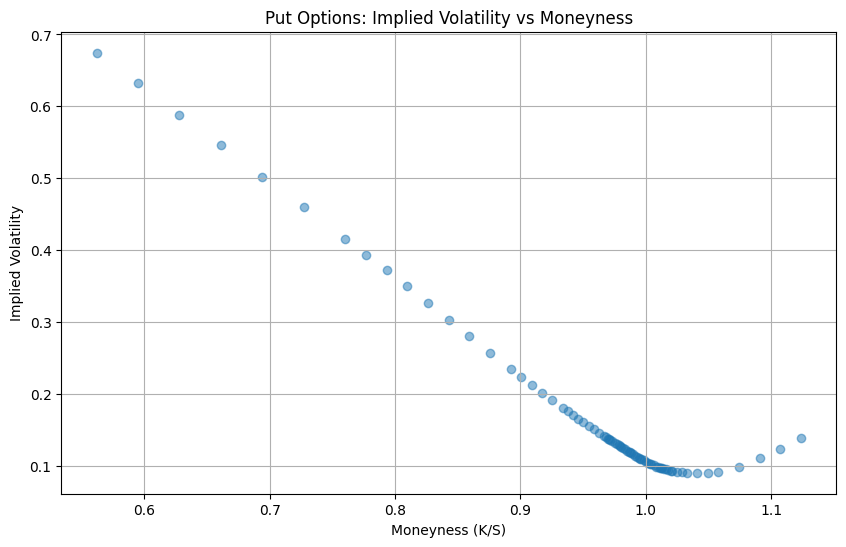

In [2]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

def black_scholes(F, K, T, r, sigma, option_type='Call'):
    """
    Calculate Black-Scholes option price
    F: forward price
    K: strike price
    T: time to maturity (in years)
    r: risk-free rate
    sigma: volatility
    option_type: 'Call' or 'Put'
    """
    d1 = (np.log(F/K) + sigma**2/2*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    
    if option_type.lower() == 'Call':
        price = F*np.exp(-r*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        price = K*np.exp(-r*T)*norm.cdf(-d2) - F*np.exp(-r*T)*norm.cdf(-d1)
    
    return price

def implied_vol_bisection(F, K, T, r, market_price, option_type='Call', tolerance=1e-5, max_iter=1000):
    """
    Calculate implied volatility using bisection method
    """
    # Set initial bounds for volatility
    sigma_low = 0.01
    sigma_high = 5.0
    
    for i in range(max_iter):
        sigma_mid = (sigma_low + sigma_high) / 2
        price = black_scholes(F, K, T, r, sigma_mid, option_type)
        
        if abs(price - market_price) < tolerance:
            return sigma_mid
        
        if price > market_price:
            sigma_high = sigma_mid
        else:
            sigma_low = sigma_mid
    
    return sigma_mid

# Filter OTM call options
otm_calls = call_options[call_options['Strike'] > current_index_price].copy()

# Calculate synthetic put prices using put-call parity
# P = C - F*exp(-rT) + K*exp(-rT)
otm_calls['Synthetic_Put_Bid'] = (otm_calls['Bid'] - forward_price * np.exp(-r * T) + 
                                 otm_calls['Strike'] * np.exp(-r * T))
otm_calls['Synthetic_Put_Ask'] = (otm_calls['Ask'] - forward_price * np.exp(-r * T) + 
                                 otm_calls['Strike'] * np.exp(-r * T))
otm_calls['Synthetic_Put_Mid'] = (otm_calls['Mid'] - forward_price * np.exp(-r * T) + 
                                 otm_calls['Strike'] * np.exp(-r * T))
otm_calls['Delta'] = otm_calls['Delta'] - np.exp(-r * T)
otm_calls['Type'] = 'Put'

# Create DataFrame with synthetic put prices
synthetic_puts = otm_calls[['Strike', 'Moneyness', 'Synthetic_Put_Bid', 
                           'Synthetic_Put_Ask', 'Synthetic_Put_Mid', 'Type', 'Volume', 'Delta', 'Open Int', 'IV']]
synthetic_puts = synthetic_puts.rename(columns={
    'Synthetic_Put_Bid': 'Bid',
    'Synthetic_Put_Ask': 'Ask',
    'Synthetic_Put_Mid': 'Mid'
})

# Concatenate real put options with synthetic put options
put_options_data = pd.concat([put_options[put_options['Strike'] <= current_index_price], synthetic_puts], ignore_index=True)
put_options_data = put_options_data.sort_values('Strike')

# Calculate IV for put options
put_options_data['IV_calculated'] = put_options_data.apply(
    lambda row: implied_vol_bisection(
        forward_price, row['Strike'], T, r, row['Mid'], 'Put', tolerance=1e-5, max_iter=1000
    ) if row['Mid'] > 0 else np.nan,
    axis=1
)


# Save the put options data to a CSV file
put_options_data.to_excel('put_options_with_IV_forward_price.xlsx', index=False)

# Create scatter plot of IV vs Moneyness for put options
plt.figure(figsize=(10, 6))
plt.scatter(put_options_data['Moneyness'], put_options_data['IV_calculated'], alpha=0.5)
plt.xlabel('Moneyness (K/S)')
plt.ylabel('Implied Volatility')
plt.title('Put Options: Implied Volatility vs Moneyness')
plt.grid(True)

# Save the plot to PDF
plt.savefig('put_options_iv_curve_forward.pdf')

plt.show()

Calculated VIX: 13.78%


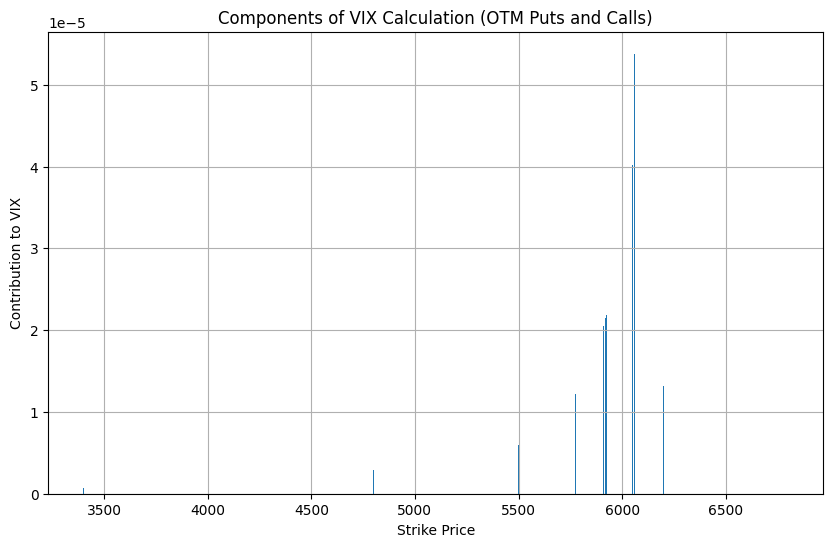

In [22]:
# Calculate VIX based on both OTM put and call options
# First, calculate the contribution of each option to VIX
def calculate_option_contribution(row, T, r):
    K = row['Strike']
    Q = row['Mid']  # Using mid price
    return (2/T) * np.exp(r*T) * Q / (K**2)

# Initialize variables for VIX calculation
sigma_squared = 0

# Get OTM call options
otm_calls = call_options[call_options['Strike'] > current_index_price].copy()
otm_puts = put_options_data[put_options_data['Strike'] < current_index_price].copy()


# Combine OTM puts and calls
all_options = pd.concat([
    otm_puts,
    otm_calls
]).sort_values('Strike')

# Calculate the contribution of each option
for i in range(1, len(all_options)-1):
    current_option = all_options.iloc[i]
    delta_K = (all_options.iloc[i+1]['Strike'] - all_options.iloc[i-1]['Strike']) / 2
    contribution = delta_K * calculate_option_contribution(current_option, T, r)
    sigma_squared += contribution

# the strike immediately below F
F_minus = all_options[all_options['Strike'] < current_index_price]['Strike'].max()

sigma_squared -= (forward_price/F_minus-1)**2 /T

# Calculate VIX (in percentage points)
VIX = 100 * np.sqrt(sigma_squared)

print(f"Calculated VIX: {VIX:.2f}%")

# Plot VIX components
contributions = all_options.apply(lambda x: calculate_option_contribution(x, T, r), axis=1)
plt.figure(figsize=(10, 6))
plt.bar(all_options['Strike'], contributions)
plt.xlabel('Strike Price')
plt.ylabel('Contribution to VIX')
plt.title('Components of VIX Calculation (OTM Puts and Calls)')
plt.grid(True)
plt.show()


In [23]:
# Implement BKM (Bakshi, Kapadia, and Madan, 2003) method for extracting moments

# Calculate quad and cubic contracts
def calculate_quad_contract(row, T, r, forward_price):
    K = row['Strike']
    Q = row['Mid'] 
    return 2*(1 - np.log(K/current_index_price))/(K**2) * Q

def calculate_cubic_contract(row, T, r, forward_price):
    K = row['Strike']
    Q = row['Mid']
    return (6*np.log(K/current_index_price) - 3*np.log(K/current_index_price)**2)/(K**2) * Q

def calculate_quartic_contract(row, T, r, forward_price):
    K = row['Strike']
    Q = row['Mid']
    return (12*np.log(K/current_index_price)**2 - 4*np.log(K/current_index_price)**3)/(K**2) * Q

# Initialize BKM contracts
V = 0  # For variance
W = 0  # For skewness  
X = 0  # For kurtosis

# Calculate contributions for each contract
for i in range(1, len(all_options)-1):
    current_option = all_options.iloc[i]
    delta_K = (all_options.iloc[i+1]['Strike'] - all_options.iloc[i-1]['Strike']) / 2
    
    V += delta_K * calculate_quad_contract(current_option, T, r, current_index_price)
    W += delta_K * calculate_cubic_contract(current_option, T, r, current_index_price)
    X += delta_K * calculate_quartic_contract(current_option, T, r, current_index_price)

# Calculate BKM moments
bkm_mu = np.exp(r*T) - 1 - np.exp(r*T)*V/2. - np.exp(r*T)*W/6. - np.exp(r*T)*X/24.
bkm_vol = np.sqrt(V*np.exp(r*T) - bkm_mu**2)
bkm_skewness = (W*np.exp(r*T) - 3*bkm_mu*V*np.exp(r*T) + 2*bkm_mu**3) / (V*np.exp(r*T) - bkm_mu**2)**(3/2)
bkm_kurtosis = (X*np.exp(r*T) - 4*bkm_mu*W*np.exp(r*T) + 6*bkm_mu**2*V*np.exp(r*T) - 3*bkm_mu**4) / (V*np.exp(r*T) - bkm_mu**2)**2

print(f"\nBKM Risk-Neutral Moments:")
print(f"Mean: {bkm_mu:.4f}")
print(f"Volatility: {bkm_vol:.4f}")
print(f"Skewness: {bkm_skewness:.4f}") 
print(f"Kurtosis: {bkm_kurtosis:.4f}")



BKM Risk-Neutral Moments:
Mean: 0.0028
Volatility: 0.0411
Skewness: -5.7389
Kurtosis: 72.0314


In [24]:
# Function to calculate NIG moments
def nig_moments(params):
    alpha, beta, delta, mu = params
    # Mean
    nig_mu = mu + delta * beta / np.sqrt(alpha**2 - beta**2)
    # Variance 
    nig_var = delta * alpha**2 / (alpha**2 - beta**2)**(3/2)
    # Skewness
    nig_skew = 3 * beta / (alpha * np.sqrt(delta * np.sqrt(alpha**2 - beta**2)))
    # Kurtosis
    nig_kurt = 3 * (1 + 4*beta**2/(alpha**2)) / (delta * np.sqrt(alpha**2 - beta**2)) + 3
    
    return nig_mu, np.sqrt(nig_var), nig_skew, nig_kurt


# Function to solve for NIG parameters by matching BKM moments
def solve_nig_params(mean, vol, skewness, kurtosis):
    def objective(params):
        alpha, beta = params
        if alpha <= abs(beta):
            return float('inf')
            
        delta = (3 * beta / (alpha * skewness))**2 / np.sqrt(alpha**2 - beta**2)
        
        mu = mean - delta * beta / np.sqrt(alpha**2 - beta**2)
        
        nig_mu, nig_vol, nig_skew, nig_kurt = nig_moments([alpha, beta, delta, mu])
        
        return max(1000*abs(vol - nig_vol), 10*abs(kurtosis - nig_kurt))

    # Define parameter grids for only alpha and beta
    alpha_grid = np.linspace(-20, 20, 100)  # Must be > |beta|
    beta_grid = np.linspace(-20, 20, 100)  # Range reduced to ensure |beta| < alpha
    
    best_value = float('inf')
    best_params = None
    
    # Grid search over just alpha and beta
    for alpha in alpha_grid:
        for beta in beta_grid:
            if alpha <= abs(beta):
                continue
                
            params = [alpha, beta]
            value = objective(params)
            
            if value < best_value:
                best_value = value
                best_params = params
    
    if best_params is None:
        raise ValueError("No valid solution found")
        
    # Fine-tune around best solution with denser grid
    alpha_fine = np.linspace(best_params[0]*0.8, best_params[0]*1.2, 20)
    beta_fine = np.linspace(best_params[1]*0.8, best_params[1]*1.2, 20)
    
    for alpha in alpha_fine:
        for beta in beta_fine:
            if alpha <= abs(beta):
                continue
                
            params = [alpha, beta]
            value = objective(params)
            
            if value < best_value:
                best_value = value
                best_params = params
    
    # Calculate final delta and mu from best alpha, beta
    alpha, beta = best_params
    delta = (3 * beta / (alpha * skewness))**2 / np.sqrt(alpha**2 - beta**2)
    mu = mean - delta * beta / np.sqrt(alpha**2 - beta**2)
    
    return [alpha, beta, delta, mu]


# Solve for NIG parameters using BKM moments
alpha_fit, beta_fit, delta_fit, mu_fit = solve_nig_params(bkm_mu, bkm_vol, bkm_skewness, bkm_kurtosis)

print("\nFitted NIG Parameters:")
print(f"alpha: {alpha_fit:.4f}")
print(f"beta: {beta_fit:.4f}")
print(f"delta: {delta_fit:.4f}")
print(f"mu: {mu_fit:.4f}")

# Compare moments
nig_mu, nig_vol, nig_skew, nig_kurt = nig_moments([alpha_fit, beta_fit, delta_fit, mu_fit])

print("\nMoment Comparison (BKM vs NIG):")
print(f"Mean: {bkm_mu:.4f} vs {nig_mu:.4f}")
print(f"Volatility: {bkm_vol:.4f} vs {nig_vol:.4f}")
print(f"Skewness: {bkm_skewness:.4f} vs {nig_skew:.4f}")
print(f"Kurtosis: {bkm_kurtosis:.4f} vs {nig_kurt:.4f}")



Fitted NIG Parameters:
alpha: 15.0643
beta: -9.9777
delta: 0.0106
mu: 0.0121

Moment Comparison (BKM vs NIG):
Mean: 0.0028 vs 0.0028
Volatility: 0.0411 vs 0.0409
Skewness: -5.7389 vs -5.7389
Kurtosis: 72.0314 vs 71.9375


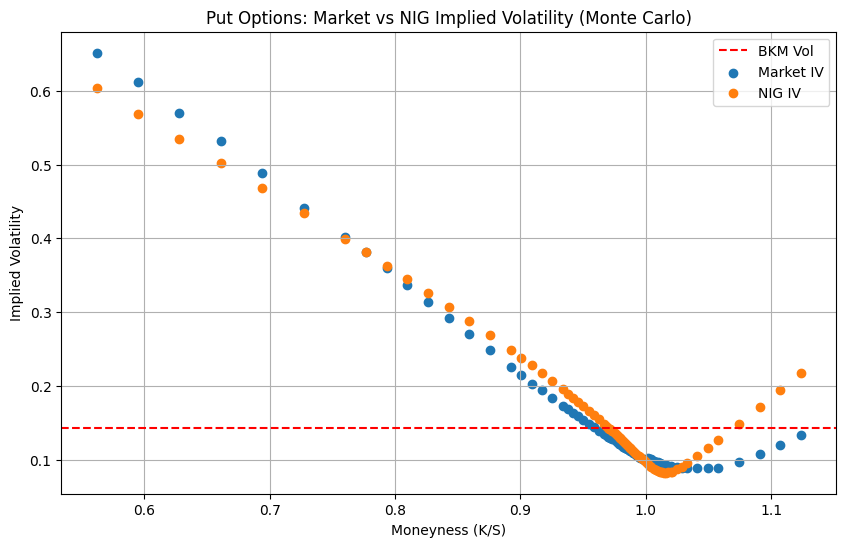


 NIG Model Errors by Moneyness:
Deep OTM: K/S < 0.94
  Absolute Error: 1.4421
  Relative Error: 36.4932%
OTM: 0.94 ≤ K/S < 0.97
  Absolute Error: 3.7449
  Relative Error: 22.4430%
ATM: 0.97 ≤ K/S < 1.03
  Absolute Error: 4.2702
  Relative Error: 6.7883%
ITM: 1.03 ≤ K/S < 1.06
  Absolute Error: 4.6887
  Relative Error: 1.7933%
Deep ITM: K/S ≥ 1.06
  Absolute Error: 5.7222
  Relative Error: 1.0526%
Overall Relative Error: 16.0793%
Overall Absolute Error: 3.5319

BS Model Errors by Moneyness:
Deep OTM: K/S < 0.94
  Absolute Error: 3.7899
  Relative Error: 93.8985%
OTM: 0.94 ≤ K/S < 0.97
  Absolute Error: 3.4227
  Relative Error: 22.2394%
ATM: 0.97 ≤ K/S < 1.03
  Absolute Error: 22.2369
  Relative Error: 35.3259%
ITM: 1.03 ≤ K/S < 1.06
  Absolute Error: 22.0609
  Relative Error: 9.6080%
Deep ITM: K/S ≥ 1.06
  Absolute Error: 6.2071
  Relative Error: 1.1970%
Overall BS Relative Error: 46.9831%
Overall BS Absolute Error: 14.3063


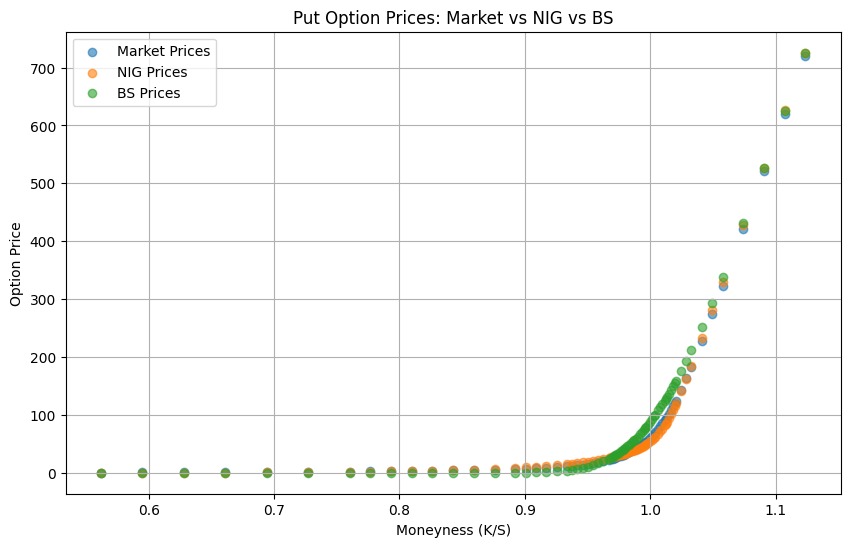

In [25]:
import scipy.stats

# Calculate NIG put option prices and implied volatilities using Monte Carlo simulation
nig_params = [alpha_fit, beta_fit, delta_fit, mu_fit]

def nig_monte_carlo(S0, params, n_paths=100000, random_seed=42):
    alpha, beta, delta, mu = params
    
    a = alpha * delta
    b = beta * delta
    loc = mu
    scale = delta
    
    # Generate stock price paths
    S_T = S0 * np.exp(scipy.stats.norminvgauss.rvs(a, b, loc, scale, size=n_paths))
    
    return S_T

# Generate terminal stock prices
S_T = nig_monte_carlo(current_index_price, nig_params)

# Calculate NIG prices and implied volatilities
nig_prices = []
nig_ivs = []

for idx, row in put_options_data.iterrows():
    strike = row['Strike']
    market_price = row['Mid']
    
    # Calculate NIG price using Monte Carlo
    put_payoffs = np.maximum(strike - S_T, 0)
    nig_price = np.exp(-r*T) * np.mean(put_payoffs)
    nig_prices.append(nig_price)
    
    # Calculate implied volatility from NIG price
    nig_iv = implied_vol_bisection(forward_price, strike, T, r, nig_price, 'Put')
    nig_ivs.append(nig_iv)
    

# Add results to dataframe
put_options_data['NIG_Price'] = nig_prices
put_options_data['NIG_IV'] = nig_ivs



# Plot market vs NIG implied volatilities
plt.figure(figsize=(10, 6))
plt.scatter(put_options_data['Moneyness'], put_options_data['IV'], label='Market IV')
plt.scatter(put_options_data['Moneyness'], put_options_data['NIG_IV'], label='NIG IV')
plt.axhline(y=bkm_vol/np.sqrt(T), color='r', linestyle='--', label='BKM Vol')
plt.xlabel('Moneyness (K/S)')
plt.ylabel('Implied Volatility')
plt.title('Put Options: Market vs NIG Implied Volatility (Monte Carlo)')
plt.legend()
plt.grid(True)

plt.savefig('nig_iv_comparison.pdf')

plt.show()

# Calculate and print errors by moneyness group
print("\n NIG Model Errors by Moneyness:")
put_options_data['NIG_Absolute_Error'] = np.abs(put_options_data['NIG_Price'] - put_options_data['Mid'])
put_options_data['NIG_Relative_Error'] = np.abs(put_options_data['NIG_Price'] - put_options_data['Mid']) / put_options_data['Mid']
for group in ['Deep OTM', 'OTM', 'ATM', 'ITM', 'Deep ITM']:
    
    mask = None
    if group == 'Deep OTM':
        print(f"{group}: K/S < 0.94")
        mask = put_options_data['Moneyness'] < 0.94
    elif group == 'OTM':
        print(f"{group}: 0.94 ≤ K/S < 0.97")
        mask = (put_options_data['Moneyness'] >= 0.94) & (put_options_data['Moneyness'] < 0.97)
    elif group == 'ATM':
        print(f"{group}: 0.97 ≤ K/S < 1.03")
        mask = (put_options_data['Moneyness'] >= 0.97) & (put_options_data['Moneyness'] < 1.03)
    elif group == 'ITM':
        print(f"{group}: 1.03 ≤ K/S < 1.06")
        mask = (put_options_data['Moneyness'] >= 1.03) & (put_options_data['Moneyness'] < 1.06)
    else:
        print(f"{group}: K/S ≥ 1.06")
        mask = put_options_data['Moneyness'] >= 1.06
    print(f"  Absolute Error: {put_options_data.loc[mask, 'NIG_Absolute_Error'].mean():.4f}")
    print(f"  Relative Error: {put_options_data.loc[mask, 'NIG_Relative_Error'].mean():.4%}")
print(f"Overall Relative Error: {put_options_data['NIG_Relative_Error'].mean():.4%}")
print(f"Overall Absolute Error: {put_options_data['NIG_Absolute_Error'].mean():.4f}")



def bs_monte_carlo(S0, params, n_paths=100000, random_seed=42):
    mu, sigma = params
    
    # Generate stock price paths
    S_T = S0 * np.exp(scipy.stats.norm.rvs(mu, sigma, size=n_paths))
    
    return S_T

ST_BS = bs_monte_carlo(current_index_price, [bkm_mu, bkm_vol])

bs_prices = []
for _, row in put_options_data.iterrows():
    put_payoff = np.maximum(row['Strike'] - ST_BS, 0)
    bs_price = np.exp(-r*T) * np.mean(put_payoff)
    bs_prices.append(bs_price)
    
put_options_data['BS_Price'] = bs_prices

# Calculate BS model errors
put_options_data['BS_Relative_Error'] = np.abs(put_options_data['BS_Price'] - put_options_data['Mid']) / put_options_data['Mid']
put_options_data['BS_Absolute_Error'] = np.abs(put_options_data['BS_Price'] - put_options_data['Mid'])

# Calculate and print BS errors by moneyness group
print("\nBS Model Errors by Moneyness:")
for group in ['Deep OTM', 'OTM', 'ATM', 'ITM', 'Deep ITM']:
    mask = None
    if group == 'Deep OTM':
        print(f"{group}: K/S < 0.94")
        mask = put_options_data['Moneyness'] < 0.94
    elif group == 'OTM':
        print(f"{group}: 0.94 ≤ K/S < 0.97")
        mask = (put_options_data['Moneyness'] >= 0.94) & (put_options_data['Moneyness'] < 0.97)
    elif group == 'ATM':
        print(f"{group}: 0.97 ≤ K/S < 1.03")
        mask = (put_options_data['Moneyness'] >= 0.97) & (put_options_data['Moneyness'] < 1.03)
    elif group == 'ITM':
        print(f"{group}: 1.03 ≤ K/S < 1.06")
        mask = (put_options_data['Moneyness'] >= 1.03) & (put_options_data['Moneyness'] < 1.06)
    else:
        print(f"{group}: K/S ≥ 1.06")
        mask = put_options_data['Moneyness'] >= 1.06
    
    print(f"  Absolute Error: {put_options_data.loc[mask, 'BS_Absolute_Error'].mean():.4f}")
    print(f"  Relative Error: {put_options_data.loc[mask, 'BS_Relative_Error'].mean():.4%}")
print(f"Overall BS Relative Error: {put_options_data['BS_Relative_Error'].mean():.4%}")
print(f"Overall BS Absolute Error: {put_options_data['BS_Absolute_Error'].mean():.4f}")

# Plot NIG prices vs market prices vs BS prices
plt.figure(figsize=(10, 6))
plt.scatter(put_options_data['Moneyness'], put_options_data['Mid'], label='Market Prices', alpha=0.6)
plt.scatter(put_options_data['Moneyness'], put_options_data['NIG_Price'], label='NIG Prices', alpha=0.6)
plt.scatter(put_options_data['Moneyness'], put_options_data['BS_Price'], label='BS Prices', alpha=0.6)
plt.xlabel('Moneyness (K/S)')
plt.ylabel('Option Price')
plt.title('Put Option Prices: Market vs NIG vs BS')
plt.legend()
plt.grid(True)
plt.savefig('put_option_prices_comparison_bs_nig_market.pdf')

plt.show()





differential_evolution step 1: f(x)= 4.23577
Current parameters: [ 1.62652548e+01 -8.75257224e+00  1.49427575e-02  1.31663502e-02], Objective value: 5000122.946264328
differential_evolution step 2: f(x)= 3.82877
Current parameters: [ 1.89761499e+01 -8.42224592e+00  1.82138616e-02  1.22016588e-02], Objective value: 5000083.846899441
differential_evolution step 3: f(x)= 3.82877
Current parameters: [ 1.89761499e+01 -8.42224592e+00  1.82138616e-02  1.22016588e-02], Objective value: 5000083.846899441
differential_evolution step 4: f(x)= 2.06618
Current parameters: [ 1.88796713e+01 -8.87111466e+00  1.75142382e-02  1.29743328e-02], Objective value: 5000111.590240744
differential_evolution step 5: f(x)= 2.06618
Current parameters: [ 1.88796713e+01 -8.87111466e+00  1.75142382e-02  1.29743328e-02], Objective value: 5000111.590240744
differential_evolution step 6: f(x)= 2.06618
Current parameters: [ 1.88796713e+01 -8.87111466e+00  1.75142382e-02  1.29743328e-02], Objective value: 5000111.59024074

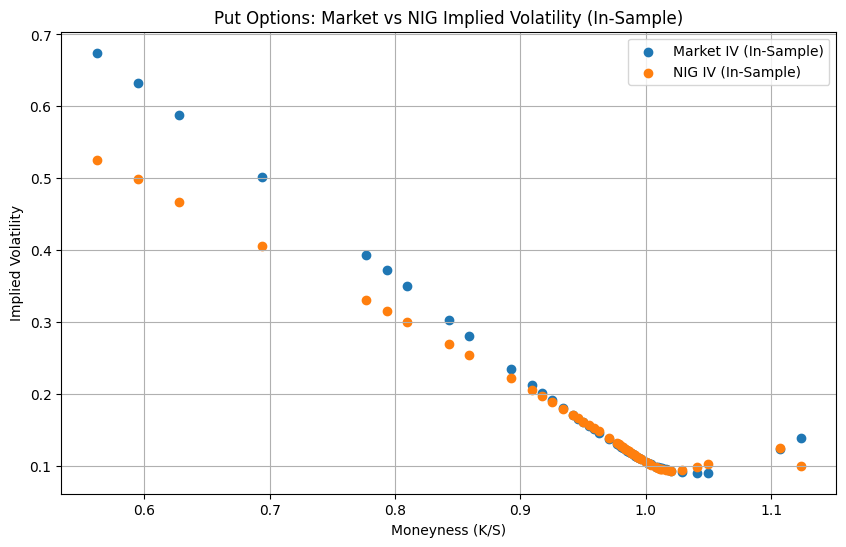

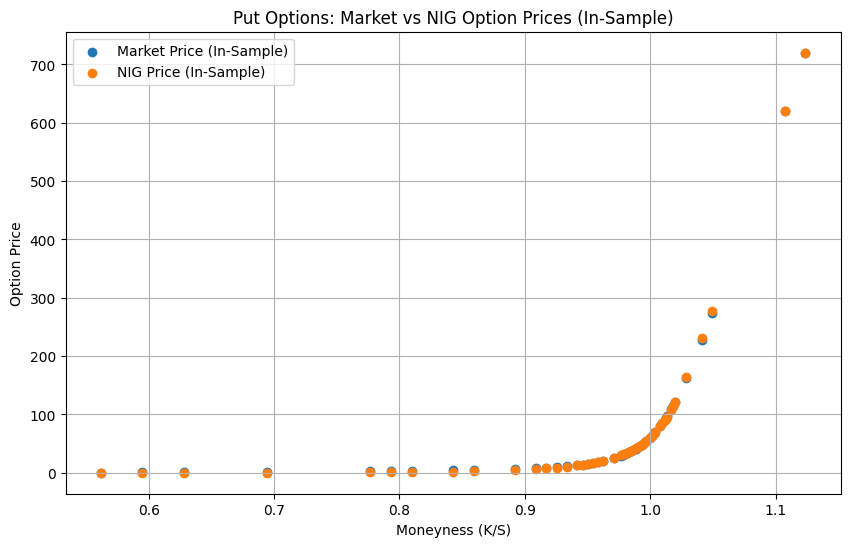

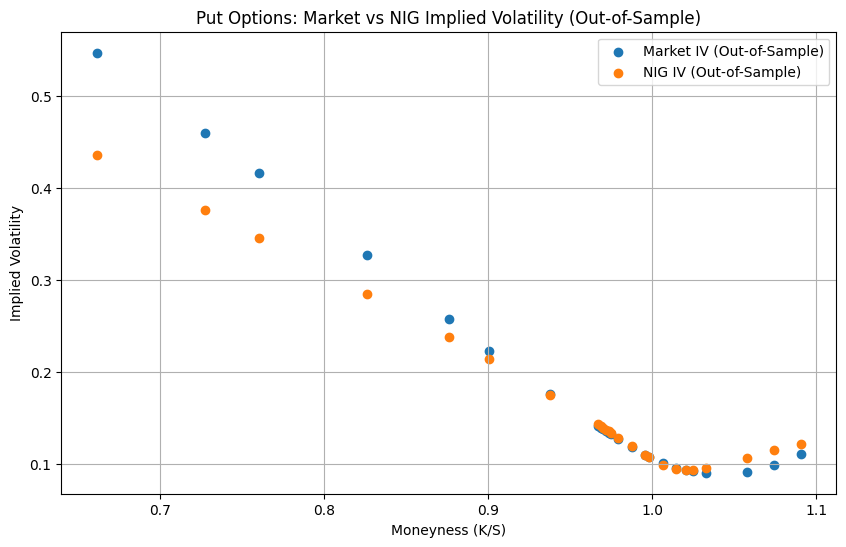

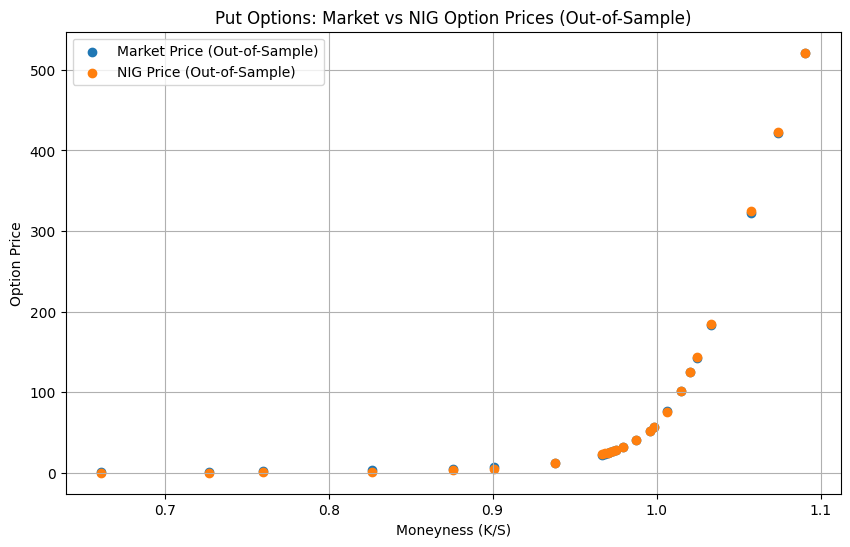


Optimized NIG Parameters:
Alpha: 20.4877
Beta: -9.8971
Delta: 0.0188
Mu: 0.0142
NIG Mean: 0.0038
NIG Volatility: 0.0369
NIG Skewness: -2.4972
NIG Kurtosis: 20.2219


In [26]:
import time

def nig_monte_carlo_base(S0, T, r, n_paths, params, U, Z, W):
    """
    Generate NIG Monte Carlo paths using base uniform and normal random variables
    
    Parameters:
    S0: Initial stock price
    T: Time to maturity
    r: Risk-free rate
    n_paths: Number of Monte Carlo paths
    params: NIG parameters
    U: Uniform(0,1) random variables
    Z: Standard normal random variables
    W: Standard normal random variables
    """
    alpha, beta, delta, mu = params

    a = alpha*delta
    b = beta*delta

    mu_ig = 1./np.sqrt(a**2 - b**2)
    y = Z**2
    x = mu_ig + mu_ig**2*y/2. - (mu_ig/2) * np.sqrt(4*mu_ig*y + mu_ig**2 * y**2)
    
    c = mu_ig/(mu_ig + x)
    accept = U <= c
    
    x[~accept] = mu_ig**2/x[~accept]
    
    X = mu + delta*(b*x + np.sqrt(x)*W)
    
    S_T = S0 * np.exp(X)
    return S_T


n_paths = 100000
np.random.seed(88)

# Generate base random variables
U = np.random.uniform(0, 1, n_paths)
Z = np.random.normal(0, 1, n_paths)
W = np.random.normal(0, 1, n_paths)

def nig_objective(params, options_data, S0, r, T):
    ST = nig_monte_carlo_base(S0, T, r, n_paths, params, U, Z, W)

    model_prices = []
    for _, row in options_data.iterrows():
        K = row['Strike']
        model_price = np.exp(-r*T) * np.mean(np.maximum(K - ST, 0))
        model_prices.append(model_price)
    
    market_prices = options_data['Mid'].values
    # Add large penalty for no-arbitrage lower bound violations
    no_arb_bounds = np.exp(-r*T) * np.maximum(0, options_data['Strike'].values - forward_price)
    arbitrage_violations = (no_arb_bounds >= np.array(model_prices)).astype(int)
    penalty = 1e6 * np.sum(arbitrage_violations)

    if np.any(np.abs(params[0]) <= abs(params[1])):
        penalty = 1e6

    return np.mean(np.abs(np.array(model_prices) - market_prices)**2) + penalty


# Define parameter bounds
bounds = [
    (15, 25),   # alpha
    (-10, -8),   # beta
    (0.006, 0.02),  # delta
    (0.008, 0.016)  # mu
]



initial_params = [15.0643, -9.9777, 0.0106, 0.0121]

# Split data into in-sample and out-of-sample
np.random.seed(88)
msk = np.random.rand(len(put_options_data)) < 0.7
put_options_data_train = put_options_data[msk]
put_options_data_test = put_options_data[~msk]


# Use differential evolution for global optimization
from scipy.optimize import differential_evolution

# Train model on in-sample data
result = differential_evolution(
    nig_objective,
    bounds,
    args=(put_options_data_train, current_index_price, r, T),
    maxiter=200,
    popsize=20,
    seed=42,
    x0=initial_params,
    callback=lambda xk, convergence: print(f"Current parameters: {xk}, Objective value: {nig_objective(xk, put_options_data_train, forward_price, r, T)}"),
    disp=True
)


best_params = result.x
nig_result = type('obj', (), {'x': best_params})
nig_params = nig_result.x

def calculate_nig_metrics(data):
    nig_prices = []
    for _, row in data.iterrows():
        K = row['Strike']
        ST = nig_monte_carlo_base(current_index_price, T, r, n_paths, nig_params, U, Z, W)
        nig_price = np.exp(-r*T) * np.mean(np.maximum(K - ST, 0))
        nig_prices.append(nig_price)
    
    data = data.copy()
    data['NIG_Price'] = nig_prices
    
    nig_ivs = []
    for _, row in data.iterrows():
        iv = implied_vol_bisection(
                forward_price,
                row['Strike'],
                T,
                r,
                row['NIG_Price'],
                'Put'
            )
        nig_ivs.append(iv)
    
    data['NIG_IV'] = nig_ivs
    return data

put_options_data_train = calculate_nig_metrics(put_options_data_train)
put_options_data_test = calculate_nig_metrics(put_options_data_test)

# Calculate and print errors by moneyness group
print("\nIn-Sample Errors by Moneyness:")
put_options_data_train['NIG_Absolute_Error'] = np.abs(put_options_data_train['NIG_Price'] - put_options_data_train['Mid'])
put_options_data_train['NIG_Relative_Error'] = np.abs(put_options_data_train['NIG_Price'] - put_options_data_train['Mid']) / put_options_data_train['Mid']
for group in ['Deep OTM', 'OTM', 'ATM', 'ITM', 'Deep ITM']:
    mask = None
    if group == 'Deep OTM':
        print(f"{group}: K/S < 0.94")
        mask = put_options_data_train['Moneyness'] < 0.94
    elif group == 'OTM':
        print(f"{group}: 0.94 ≤ K/S < 0.97")
        mask = (put_options_data_train['Moneyness'] >= 0.94) & (put_options_data_train['Moneyness'] < 0.97)
    elif group == 'ATM':
        print(f"{group}: 0.97 ≤ K/S < 1.03")
        mask = (put_options_data_train['Moneyness'] >= 0.97) & (put_options_data_train['Moneyness'] < 1.03)
    elif group == 'ITM':
        print(f"{group}: 1.03 ≤ K/S < 1.06")
        mask = (put_options_data_train['Moneyness'] >= 1.03) & (put_options_data_train['Moneyness'] < 1.06)
    else:
        print(f"{group}: K/S ≥ 1.06")
        mask = put_options_data_train['Moneyness'] >= 1.06
    print(f"  Absolute Error: {put_options_data_train.loc[mask, 'NIG_Absolute_Error'].mean():.4f}")
    print(f"  Relative Error: {put_options_data_train.loc[mask, 'NIG_Relative_Error'].mean():.4%}")
print(f"Overall In-Sample Relative Error: {put_options_data_train['NIG_Relative_Error'].mean():.4%}")
print(f"Overall In-Sample Absolute Error: {put_options_data_train['NIG_Absolute_Error'].mean():.4f}")

print("\nOut-of-Sample Errors by Moneyness:")
put_options_data_test['NIG_Absolute_Error'] = np.abs(put_options_data_test['NIG_Price'] - put_options_data_test['Mid'])
put_options_data_test['NIG_Relative_Error'] = np.abs(put_options_data_test['NIG_Price'] - put_options_data_test['Mid']) / put_options_data_test['Mid']
for group in ['Deep OTM', 'OTM', 'ATM', 'ITM', 'Deep ITM']:
    mask = None
    if group == 'Deep OTM':
        print(f"{group}: K/S < 0.94")
        mask = put_options_data_test['Moneyness'] < 0.94
    elif group == 'OTM':
        print(f"{group}: 0.94 ≤ K/S < 0.97")
        mask = (put_options_data_test['Moneyness'] >= 0.94) & (put_options_data_test['Moneyness'] < 0.97)
    elif group == 'ATM':
        print(f"{group}: 0.97 ≤ K/S < 1.03")
        mask = (put_options_data_test['Moneyness'] >= 0.97) & (put_options_data_test['Moneyness'] < 1.03)
    elif group == 'ITM':
        print(f"{group}: 1.03 ≤ K/S < 1.06")
        mask = (put_options_data_test['Moneyness'] >= 1.03) & (put_options_data_test['Moneyness'] < 1.06)
    else:
        print(f"{group}: K/S ≥ 1.06")
        mask = put_options_data_test['Moneyness'] >= 1.06
    print(f"  Absolute Error: {put_options_data_test.loc[mask, 'NIG_Absolute_Error'].mean():.4f}")
    print(f"  Relative Error: {put_options_data_test.loc[mask, 'NIG_Relative_Error'].mean():.4%}")
print(f"Overall Out-of-Sample Relative Error: {put_options_data_test['NIG_Relative_Error'].mean():.4%}")
print(f"Overall Out-of-Sample Absolute Error: {put_options_data_test['NIG_Absolute_Error'].mean():.4f}")

# Plot market vs DEJD implied volatilities for in-sample data
plt.figure(figsize=(10, 6))
plt.scatter(put_options_data_train['Moneyness'], put_options_data_train['IV_calculated'], label='Market IV (In-Sample)')
plt.scatter(put_options_data_train['Moneyness'], put_options_data_train['NIG_IV'], label='NIG IV (In-Sample)')
plt.xlabel('Moneyness (K/S)')
plt.ylabel('Implied Volatility')
plt.title('Put Options: Market vs NIG Implied Volatility (In-Sample)')
plt.legend()
plt.grid(True)
plt.savefig('nig_iv_comparison_in_sample.pdf')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(put_options_data_train['Moneyness'], put_options_data_train['Mid'], label='Market Price (In-Sample)')
plt.scatter(put_options_data_train['Moneyness'], put_options_data_train['NIG_Price'], label='NIG Price (In-Sample)')
plt.xlabel('Moneyness (K/S)')
plt.ylabel('Option Price')
plt.title('Put Options: Market vs NIG Option Prices (In-Sample)')
plt.legend()
plt.grid(True)
plt.savefig('nig_price_comparison_in_sample.pdf')
plt.show()

# Plot market vs DEJD implied volatilities for out-of-sample data
plt.figure(figsize=(10, 6))
plt.scatter(put_options_data_test['Moneyness'], put_options_data_test['IV_calculated'], label='Market IV (Out-of-Sample)')
plt.scatter(put_options_data_test['Moneyness'], put_options_data_test['NIG_IV'], label='NIG IV (Out-of-Sample)')
plt.xlabel('Moneyness (K/S)')
plt.ylabel('Implied Volatility')
plt.title('Put Options: Market vs NIG Implied Volatility (Out-of-Sample)')
plt.legend()
plt.grid(True)
plt.savefig('nig_iv_comparison_out_sample.pdf')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(put_options_data_test['Moneyness'], put_options_data_test['Mid'], label='Market Price (Out-of-Sample)')
plt.scatter(put_options_data_test['Moneyness'], put_options_data_test['NIG_Price'], label='NIG Price (Out-of-Sample)')
plt.xlabel('Moneyness (K/S)')
plt.ylabel('Option Price')
plt.title('Put Options: Market vs NIG Option Prices (Out-of-Sample)')
plt.legend()
plt.grid(True)
plt.savefig('nig_price_comparison_out_sample.pdf')
plt.show()

# Print optimized parameters
print("\nOptimized NIG Parameters:")
print(f"Alpha: {nig_params[0]:.4f}")
print(f"Beta: {nig_params[1]:.4f}")
print(f"Delta: {nig_params[2]:.4f}")
print(f"Mu: {nig_params[3]:.4f}")
params = [nig_params[0], nig_params[1], nig_params[2], nig_params[3]]
nig_mu, nig_vol, nig_skew, nig_kurt = nig_moments(params)
print(f"NIG Mean: {nig_mu:.4f}")
print(f"NIG Volatility: {nig_vol:.4f}")
print(f"NIG Skewness: {nig_skew:.4f}")
print(f"NIG Kurtosis: {nig_kurt:.4f}")


differential_evolution step 1: f(x)= 30533.3
Current parameters: [ 0.16053062  0.28221746  0.50304997  0.3494263  33.32813397 34.10759107], Objective value: 30533.25409819312
differential_evolution step 2: f(x)= 30533.3
Current parameters: [ 0.16053062  0.28221746  0.50304997  0.3494263  33.32813397 34.10759107], Objective value: 30533.25409819312
differential_evolution step 3: f(x)= 30533.3
Current parameters: [ 0.16053062  0.28221746  0.50304997  0.3494263  33.32813397 34.10759107], Objective value: 30533.25409819312
differential_evolution step 4: f(x)= 30533.3
Current parameters: [ 0.16053062  0.28221746  0.50304997  0.3494263  33.32813397 34.10759107], Objective value: 30533.25409819312
differential_evolution step 5: f(x)= 30533.3
Current parameters: [ 0.16053062  0.28221746  0.50304997  0.3494263  33.32813397 34.10759107], Objective value: 30533.25409819312
differential_evolution step 6: f(x)= 30533.3
Current parameters: [ 0.16053062  0.28221746  0.50304997  0.3494263  33.32813397

/var/folders/wk/l91h38n17q9g2sxscxvjlmmm0000gn/T/ipykernel_57352/3026816481.py:16: RuntimeWarning: overflow encountered in exp
  return S0 * np.exp(normal_part + jump_part)
/var/folders/wk/l91h38n17q9g2sxscxvjlmmm0000gn/T/ipykernel_57352/3026816481.py:16: RuntimeWarning: overflow encountered in multiply
  return S0 * np.exp(normal_part + jump_part)


differential_evolution step 23: f(x)= 7937.78
Current parameters: [-1.37959147e-02  1.49042427e-02  7.15002642e-01  8.87902767e-01
  4.94672044e+01  3.54451283e+00], Objective value: 7937.778938283302
differential_evolution step 24: f(x)= 4153.25
Current parameters: [-8.78897986e-03  1.62423592e-02  6.69229934e-01  8.67534890e-01
  1.13535923e+02  5.70079975e+00], Objective value: 4153.253989459509
differential_evolution step 25: f(x)= 4153.25
Current parameters: [-8.78897986e-03  1.62423592e-02  6.69229934e-01  8.67534890e-01
  1.13535923e+02  5.70079975e+00], Objective value: 4153.253989459509
differential_evolution step 26: f(x)= 4153.25
Current parameters: [-8.78897986e-03  1.62423592e-02  6.69229934e-01  8.67534890e-01
  1.13535923e+02  5.70079975e+00], Objective value: 4153.253989459509
differential_evolution step 27: f(x)= 4153.25
Current parameters: [-8.78897986e-03  1.62423592e-02  6.69229934e-01  8.67534890e-01
  1.13535923e+02  5.70079975e+00], Objective value: 4153.25398945

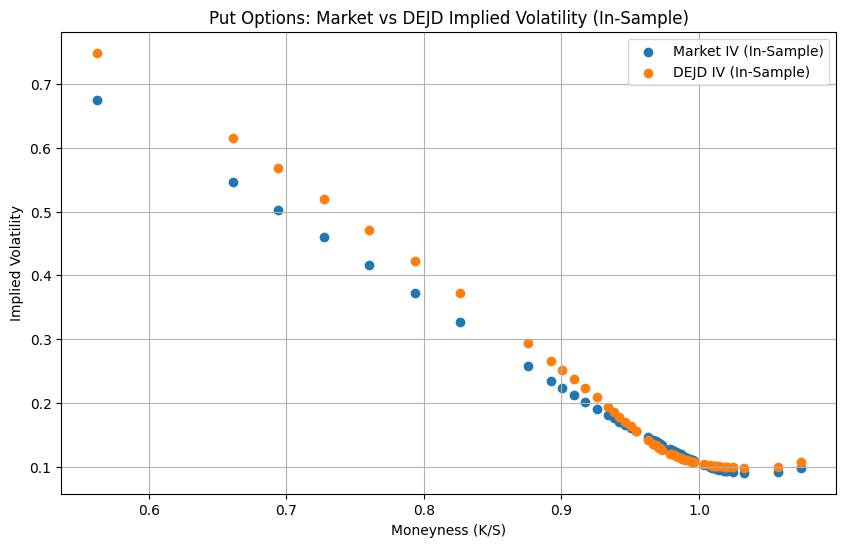

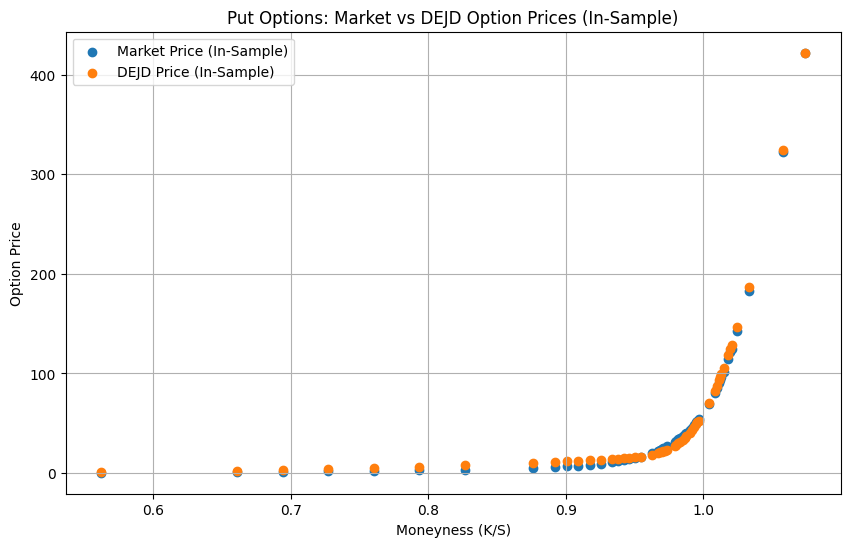

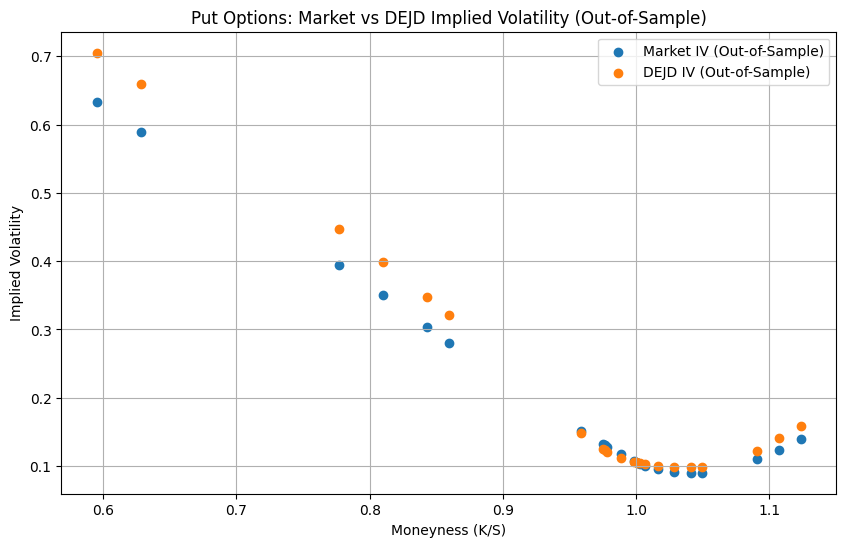

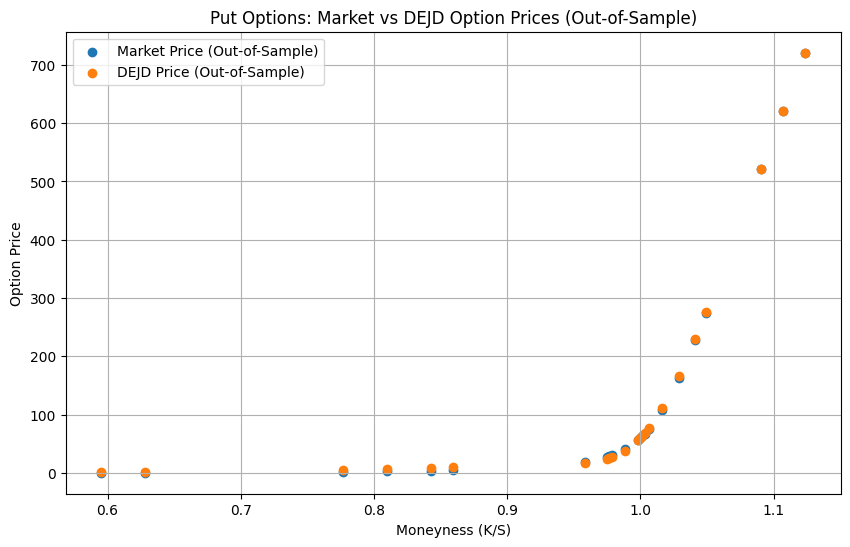


Optimized DEJD Parameters:
Mu: 0.0048
Sigma: 0.0251
Lambda: 0.6195
p: 0.9742
eta1: 239.6988
eta2: 3.5663


In [27]:
# Define the Double Exponential Jump Diffusion (DEJD) model parameters
def simulate_dejd_path(S0, N, params, normal_rv, uniform_rv1, uniform_rv2, exp_rv):
    mu, sigma, lambda_j, p, eta1, eta2 = params
    
    normal_part = mu + sigma * normal_rv
    
    jump_part = np.zeros(N)
    jumps = uniform_rv1 < lambda_j
    pos_jumps = jumps & (uniform_rv2 < p)
    neg_jumps = jumps & ~(uniform_rv2 < p)
    
    # Add jump
    jump_part[pos_jumps] = exp_rv[pos_jumps]/eta1  # Positive jumps
    jump_part[neg_jumps] = -exp_rv[neg_jumps]/eta2  # Negative jumps
            
    return S0 * np.exp(normal_part + jump_part)


np.random.seed(42)
n_paths = 10000
normal_rv = np.random.normal(0, 1, n_paths)
uniform_rv1 = np.random.uniform(0, 1, n_paths)
uniform_rv2 = np.random.uniform(0, 1, n_paths)
exp_rv = np.random.exponential(1, n_paths)

def dejd_objective(params, options_data, S0, r, T):
    ST = simulate_dejd_path(S0, n_paths, params, normal_rv, uniform_rv1, uniform_rv2, exp_rv)
    model_prices = []
    for _, row in options_data.iterrows():
        K = row['Strike']
        model_price = np.exp(-r*T) * np.mean(np.maximum(K - ST, 0))
        model_prices.append(model_price)
    
    market_prices = options_data['Mid'].values
    no_arb_bounds = np.exp(-r*T) * np.maximum(0, options_data['Strike'].values - forward_price)
    arbitrage_violations = (no_arb_bounds + 1.0 >= np.array(model_prices)).astype(int)
    penalty = 1e6 * np.sum(arbitrage_violations)

    return np.mean(np.abs((np.array(model_prices) - market_prices))**2) + penalty

# Initial parameter guess
initial_params = [0.0121, 0.0221, 0.6530, 0.9750, 69.9764, 3.6434]  # [mu, sigma, lambda_j, p, eta1, eta2]

# Define parameter bounds
bounds = [
    (-1.0, 1.0),   # mu
    (0.001, 1.0),   # sigma
    (0.5, 1.0),   # lambda_j
    (0.001, 1.0),  # p
    (0.001, 300.0),  # eta1
    (0.001, 100.0)   # eta2
]

# Use differential evolution for global optimization
from scipy.optimize import differential_evolution

# Split data into in-sample and out-of-sample
np.random.seed(42)
msk = np.random.rand(len(put_options_data)) < 0.7
put_options_data_train = put_options_data[msk]
put_options_data_test = put_options_data[~msk]

# Train model on in-sample data
result = differential_evolution(
    dejd_objective,
    bounds,
    args=(put_options_data_train, current_index_price, r, T),
    maxiter=200,
    popsize=20,
    seed=42,
    x0=initial_params,
    callback=lambda xk, convergence: print(f"Current parameters: {xk}, Objective value: {dejd_objective(xk, put_options_data_train, current_index_price, r, T)}"),
    disp=True
)

best_params = result.x
dejd_result = type('obj', (), {'x': best_params})
dejd_params = dejd_result.x

def calculate_dejd_metrics(data):
    dejd_prices = []
    for _, row in data.iterrows():
        K = row['Strike']
        ST = simulate_dejd_path(current_index_price, n_paths, dejd_params, normal_rv, uniform_rv1, uniform_rv2, exp_rv)
        dejd_price = np.exp(-r*T) * np.mean(np.maximum(K - ST, 0))
        dejd_prices.append(dejd_price)
    
    data = data.copy()
    data['DEJD_Price'] = dejd_prices
    
    dejd_ivs = []
    for _, row in data.iterrows():
        iv = implied_vol_bisection(
                forward_price,
                row['Strike'],
                T,
                r,
                row['DEJD_Price'],
                'Put'
            )
        dejd_ivs.append(iv)
    
    data['DEJD_IV'] = dejd_ivs
    return data

put_options_data_train = calculate_dejd_metrics(put_options_data_train)
put_options_data_test = calculate_dejd_metrics(put_options_data_test)

# Calculate and print errors by moneyness group
print("\nIn-Sample Errors by Moneyness:")

put_options_data_train['DEJD_Absolute_Error'] = np.abs(put_options_data_train['DEJD_Price'] - put_options_data_train['Mid'])
put_options_data_train['DEJD_Relative_Error'] = np.abs(put_options_data_train['DEJD_Price'] - put_options_data_train['Mid']) / put_options_data_train['Mid']

for group in ['Deep OTM', 'OTM', 'ATM', 'ITM', 'Deep ITM']:
    mask = None
    if group == 'Deep OTM':
        print(f"{group}: K/S < 0.94")
        mask = put_options_data_train['Moneyness'] < 0.94
    elif group == 'OTM':
        print(f"{group}: 0.94 ≤ K/S < 0.97")
        mask = (put_options_data_train['Moneyness'] >= 0.94) & (put_options_data_train['Moneyness'] < 0.97)
    elif group == 'ATM':
        print(f"{group}: 0.97 ≤ K/S < 1.03")
        mask = (put_options_data_train['Moneyness'] >= 0.97) & (put_options_data_train['Moneyness'] < 1.03)
    elif group == 'ITM':
        print(f"{group}: 1.03 ≤ K/S < 1.06")
        mask = (put_options_data_train['Moneyness'] >= 1.03) & (put_options_data_train['Moneyness'] < 1.06)
    else:
        print(f"{group}: K/S ≥ 1.06")
        mask = put_options_data_train['Moneyness'] >= 1.06
    print(f"  Absolute Error: {put_options_data_train.loc[mask, 'DEJD_Absolute_Error'].mean():.4f}")
    print(f"  Relative Error: {put_options_data_train.loc[mask, 'DEJD_Relative_Error'].mean():.4%}")
print(f"Overall In-Sample Relative Error: {put_options_data_train['DEJD_Relative_Error'].mean():.4%}")
print(f"Overall In-Sample Absolute Error: {put_options_data_train['DEJD_Absolute_Error'].mean():.4f}")

print("\nOut-of-Sample Errors by Moneyness:")
put_options_data_test['DEJD_Absolute_Error'] = np.abs(put_options_data_test['DEJD_Price'] - put_options_data_test['Mid'])
put_options_data_test['DEJD_Relative_Error'] = np.abs(put_options_data_test['DEJD_Price'] - put_options_data_test['Mid']) / put_options_data_test['Mid']

for group in ['Deep OTM', 'OTM', 'ATM', 'ITM', 'Deep ITM']:
    mask = None
    if group == 'Deep OTM':
        print(f"{group}: K/S < 0.94")
        mask = put_options_data_test['Moneyness'] < 0.94
    elif group == 'OTM':
        print(f"{group}: 0.94 ≤ K/S < 0.97")
        mask = (put_options_data_test['Moneyness'] >= 0.94) & (put_options_data_test['Moneyness'] < 0.97)
    elif group == 'ATM':
        print(f"{group}: 0.97 ≤ K/S < 1.03")
        mask = (put_options_data_test['Moneyness'] >= 0.97) & (put_options_data_test['Moneyness'] < 1.03)
    elif group == 'ITM':
        print(f"{group}: 1.03 ≤ K/S < 1.06")
        mask = (put_options_data_test['Moneyness'] >= 1.03) & (put_options_data_test['Moneyness'] < 1.06)
    else:
        print(f"{group}: K/S ≥ 1.06")
        mask = put_options_data_test['Moneyness'] >= 1.06
    print(f"  Absolute Error: {put_options_data_test.loc[mask, 'DEJD_Absolute_Error'].mean():.4f}")
    print(f"  Relative Error: {put_options_data_test.loc[mask, 'DEJD_Relative_Error'].mean():.4%}")
print(f"Overall Out-of-Sample Relative Error: {put_options_data_test['DEJD_Relative_Error'].mean():.4%}")
print(f"Overall Out-of-Sample Absolute Error: {put_options_data_test['DEJD_Absolute_Error'].mean():.4f}")

# Plot market vs DEJD implied volatilities for in-sample data
plt.figure(figsize=(10, 6))
plt.scatter(put_options_data_train['Moneyness'], put_options_data_train['IV_calculated'], label='Market IV (In-Sample)')
plt.scatter(put_options_data_train['Moneyness'], put_options_data_train['DEJD_IV'], label='DEJD IV (In-Sample)')
plt.xlabel('Moneyness (K/S)')
plt.ylabel('Implied Volatility')
plt.title('Put Options: Market vs DEJD Implied Volatility (In-Sample)')
plt.legend()
plt.grid(True)
plt.savefig('dejd_iv_comparison_in_sample.pdf')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(put_options_data_train['Moneyness'], put_options_data_train['Mid'], label='Market Price (In-Sample)')
plt.scatter(put_options_data_train['Moneyness'], put_options_data_train['DEJD_Price'], label='DEJD Price (In-Sample)')
plt.xlabel('Moneyness (K/S)')
plt.ylabel('Option Price')
plt.title('Put Options: Market vs DEJD Option Prices (In-Sample)')
plt.legend()
plt.grid(True)
plt.savefig('dejd_price_comparison_in_sample.pdf')
plt.show()

# Plot market vs DEJD implied volatilities for out-of-sample data
plt.figure(figsize=(10, 6))
plt.scatter(put_options_data_test['Moneyness'], put_options_data_test['IV_calculated'], label='Market IV (Out-of-Sample)')
plt.scatter(put_options_data_test['Moneyness'], put_options_data_test['DEJD_IV'], label='DEJD IV (Out-of-Sample)')
plt.xlabel('Moneyness (K/S)')
plt.ylabel('Implied Volatility')
plt.title('Put Options: Market vs DEJD Implied Volatility (Out-of-Sample)')
plt.legend()
plt.grid(True)
plt.savefig('dejd_iv_comparison_out_sample.pdf')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(put_options_data_test['Moneyness'], put_options_data_test['Mid'], label='Market Price (Out-of-Sample)')
plt.scatter(put_options_data_test['Moneyness'], put_options_data_test['DEJD_Price'], label='DEJD Price (Out-of-Sample)')
plt.xlabel('Moneyness (K/S)')
plt.ylabel('Option Price')
plt.title('Put Options: Market vs DEJD Option Prices (Out-of-Sample)')
plt.legend()
plt.grid(True)
plt.savefig('dejd_price_comparison_out_sample.pdf')
plt.show()

# Print optimized parameters
print("\nOptimized DEJD Parameters:")
print(f"Mu: {dejd_params[0]:.4f}")
print(f"Sigma: {dejd_params[1]:.4f}")
print(f"Lambda: {dejd_params[2]:.4f}")
print(f"p: {dejd_params[3]:.4f}")
print(f"eta1: {dejd_params[4]:.4f}")
print(f"eta2: {dejd_params[5]:.4f}")


